# Attribution of weather features to precipitation in Victoria, Australia

Preliminary analysis for attribution of precipitation to weather features, cyclones, fronts and moisture transport axes (MTAs), following Konstali et al. (2024). 

This analysis is based on an example notebook provided by Michael Barnes. 

## Software
- Based on ACCESS-NRI's NCI xp65 anaylsis3-25.11 conda environment
- Uses  M. Barnes local installation of dynlib
    - https://folk.uib.no/csp001/dynlib_doc/
    - https://git.app.uib.no/Clemens.Spensberger/dynlib/-/blob/master/

## Data
- ERA5 total precipitation (tp) and geopotential for cyclone detection (project rt52 on NCI)
    - https://confluence.ecmwf.int/spaces/CKB/pages/76414402/ERA5+data+documentation
- EAR5 weather objects (cyclones, fronts, MTAs; see references)

## References
- Spensberger, C. (2023). ERA5 jet axes 1979-2022 [Data set]. NIRD RDA. https://doi.org/10.11582/2023.00120
- Spensberger, C., Marcheggiani, A. (2024). ERA5 cyclone tracks [Data set]. NIRD RDA. https://doi.org/10.11582/2024.00023
- Spensberger, C. (2024). ERA5 cyclones, anticyclones, fronts and cold-air outbreaks [Data set]. NIRD RDA. https://doi.org/10.11582/2024.00095 
- Spensberger, C. (2024). ERA5 moisture transport axis detections [Data set]. NIRD RDA. https://doi.org/10.11582/2024.00178
- Konstali, K., C. Spensberger, T. Spengler, and A. Sorteberg, 2024: Global Attribution of Precipitation to Weather Features. J. Climate, 37, 1181–1196, https://doi.org/10.1175/JCLI-D-23-0293.1.

In [ ]:
# Import local dynlib (not sure if all necessary, but it works)
import os
import sys
import importlib.util

pkg_dir = "/g/data/xv83/mb0427/dynlib-1.6.1.dev7+g2e093da-py3.11.egg"
wxsys_dir = "/g/data/gb02/mb0427/WxSysLib"

os.environ["WXSYSLIBDIR"] = wxsys_dir
os.environ["DYNLIBDIR"] = pkg_dir

sys.path.insert(0, pkg_dir)
sys.path.insert(0, wxsys_dir)

importlib.invalidate_caches()

import dynlib
from dynlib import utils, gridlib, dynfor, detect

In [1]:
import calendar
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmaps
from datetime import datetime, timedelta
from dask.distributed import Client
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import xarray as xr

# from xclim.core import units

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xv83/as3189/conda/envs/unseen/share/proj failed


In [ ]:
ds = xr.open_dataset(
    "/g/data/xv83/as3189/vicwaci/data/precip_attribution/ERA5_precip_attribution_198411_aus_min30gpm.nc"
)

In [3]:
ds

<xarray.Dataset> Size: 711MB
Dimensions:    (time: 240, latitude: 121, longitude: 180)
Coordinates:
  * time       (time) datetime64[ns] 2kB 1984-11-01 ... 1984-11-30T21:00:00
  * latitude   (latitude) float32 484B -5.0 -5.5 -6.0 -6.5 ... -64.0 -64.5 -65.0
  * longitude  (longitude) float32 720B 90.0 90.5 91.0 ... 178.5 179.0 179.5
Data variables: (12/17)
    U          (time, latitude, longitude) float64 42MB ...
    M          (time, latitude, longitude) float64 42MB ...
    F          (time, latitude, longitude) float64 42MB ...
    FM         (time, latitude, longitude) float64 42MB ...
    V          (time, latitude, longitude) float64 42MB ...
    VM         (time, latitude, longitude) float64 42MB ...
    ...         ...
    CFM        (time, latitude, longitude) float64 42MB ...
    CV         (time, latitude, longitude) float64 42MB ...
    CVM        (time, latitude, longitude) float64 42MB ...
    CVF        (time, latitude, longitude) float64 42MB ...
    CVFM       (time, latitude, longitude) float64 42MB ...
    total      (time, latitude, longitude) float64 42MB ...
Attributes:
    description:  Precipitation attribution to weather features (cyclones, fr...
    history:      2026-09-14 02:08:13 by 1.6.1-7-g2e093da

In [4]:
y1, y2 = "1984", "1984"
date_range = xr.date_range(f"{y1}-01-01", f"{y2}-12-31", freq="1MS")
date_range

DatetimeIndex(['1984-01-01', '1984-02-01', '1984-03-01', '1984-04-01',
               '1984-05-01', '1984-06-01', '1984-07-01', '1984-08-01',
               '1984-09-01', '1984-10-01', '1984-11-01', '1984-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [18]:
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33789 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/33789/status,
Dashboard: /proxy/33789/status,Workers: 4
Total threads: 4,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42137,Workers: 0
Dashboard: /proxy/33789/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37329,Total threads: 1
Dashboard: /proxy/33673/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:36791,


In [4]:
# path_obj = "/g/data/xv83/mb0427/VicWaCI/data/bergen_obj"
path_obj = "/g/data/xv83/as3189/vicwaci/data/weather_features"
lat_slice, lon_slice = slice(-5, -65), slice(90, 180)

# Examine input datasets

In [5]:
# Pick a date
dt = xr.date_range("2021-11-01", "2021-11-01", freq="1MS")[0]
time_str = dt.strftime("%Y%m")
time_str

'202111'

## Weather feature datasets
### Cyclones

In [7]:
# ERA5 Cyclones (ETH)
ds_cyc = xr.open_dataset(f"{path_obj}/cyclones_ETH/ea.ans.{time_str}.sfc.cycmask.nc")
ds_cyc

<xarray.Dataset> Size: 62MB
Dimensions:    (time: 240, latitude: 361, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2021-11-01 ... 2021-11-30T21:00:00
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Data variables:
    cycmask    (time, latitude, longitude) int8 62MB ...
Attributes:
    Conventions:  CF-1.0
    history:      2023-05-05 18:12:50 CEST by 1.3.2-7-g0f42abd

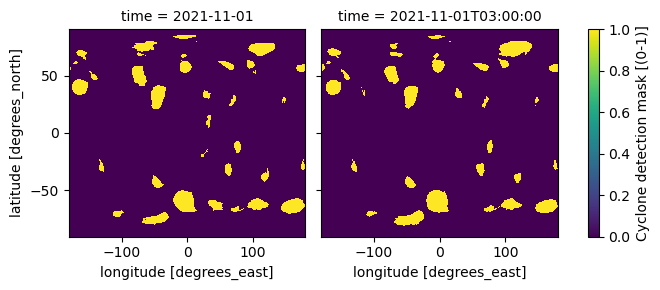

In [8]:
ds_cyc.cycmask.isel(time=slice(2)).plot(col="time")
ds_cyc.close()

In [9]:
# ERA5 cyclones (Melbourne)
ds_cyc2 = xr.open_dataset(f"{path_obj}/cyclones/ea.ans.{time_str}.sfc.tracks.nc")
ds_cyc2
ds_cyc2.close()

### Fronts

In [10]:
# ERA5 fronts
ds_fronts = xr.open_dataset(f"{path_obj}/fronts/ea.ans.{time_str}.850.frovo_id.nc")
ds_fronts

<xarray.Dataset> Size: 125MB
Dimensions:    (time: 240, lev: 1, latitude: 361, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2021-11-01 ... 2021-11-30T21:00:00
  * lev        (lev) float32 4B 8.5e+04
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Data variables:
    frovo_id   (time, lev, latitude, longitude) int16 125MB ...
Attributes:
    Conventions:  CF-1.0
    history:      2023-09-22 12:38:33 CEST by 1.3.3-5-g303d1a1+

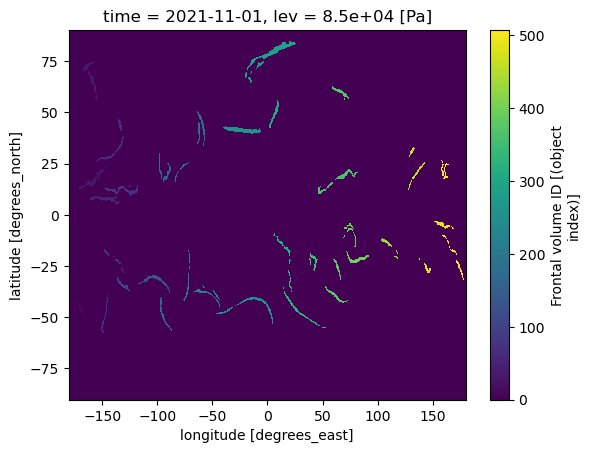

In [11]:
ds_fronts.frovo_id.isel(time=0, lev=0).plot()
ds_fronts.close()

### MTAs

In [ ]:
def mta_lines_to_mask(ds, grid):
    """Convert MTA lines to a mask on the target grid.

    Parameters
    ----------
    ds: Dataset of MTA lines (dims=index)
    grid: Dataset containing target latitude and longitude

    Returns
    -------
    mask : xarray.DataArray
        Mask of shape (time, latitude, longitude)
    """

    ds = ds.rename({"date": "time"})
    # Convert to DataFrame
    df = ds[["time", "latitude", "longitude", "viwvt"]].to_dataframe()
    df = df.reset_index(drop=True)

    # Convert positions to nearest lat/lon values
    df["latitude"] = grid.latitude.sel(latitude=xr.DataArray(df.latitude), method="nearest").values
    df["longitude"] = grid.longitude.sel(
        longitude=xr.DataArray(df.longitude), method="nearest"
    ).values

    # If several points fall into the same grid cell, retain the maximum viwvt.
    df = df.groupby(["time", "latitude", "longitude"], as_index=False)["viwvt"].max()
    # Convert back to xarray
    mask = df.set_index(["time", "latitude", "longitude"])["viwvt"].to_xarray()

    # Ensure time, lat lon grids are complete
    mask = mask.reindex(
        time=np.unique(ds.time),
        latitude=grid.latitude,
        longitude=grid.longitude,
        fill_value=np.nan,
    )
    return mask

In [ ]:
def convert_to_dynlib_lines(ds, grid):
    """Convert point-based line data to arrays suitable for mask_lines_with_data().

    Parameters
    ----------
    ds: Dataset of MTA lines (dims=index)
    grid: Dataset containing target latitude and longitude

    Returns
    -------
    lines : np.ndarray(time, pointindex, 3)

        lines[..., 0] = xidx
        lines[..., 1] = yidx
        lines[..., 2] = viwvt

    loff : np.ndarray
        Shape (time, lineindex)
        1-based starting point indices, as expected by dynlib.
    """

    # Input data
    viwvt = ds["viwvt"].values
    dates = ds["date"].values
    line_ids = ds["line_id"].values

    # Convert lon/lat to index of nearest grid.
    # Add 1 because dynlib uses Fortran-style 1-based indexing.
    xidx = np.abs(grid["longitude"] - ds["longitude"]).argmin("longitude").values + 1
    yidx = np.abs(grid["latitude"] - ds["latitude"]).argmin("latitude").values + 1
    times = np.unique(dates)

    # Number of lines at each timestep
    lines_per_time = [np.unique(line_ids[dates == t]) for t in times]

    # Maximum number of lines/points belonging to any timestep
    max_nlines = max(len(x) for x in lines_per_time)
    max_npoints = max(np.sum(dates == t) for t in times)

    lines = np.full((len(times), max_npoints, 3), np.nan, dtype=np.float32)
    # -1 means no line in this slot.
    loff = np.full((len(times), max_nlines), -1, dtype=np.int32)

    for t, time in enumerate(times):
        time_mask = dates == time
        ids = lines_per_time[t]
        i = 0

        for n, line_id in enumerate(ids):
            mask = time_mask & (line_ids == line_id)
            x = xidx[mask]
            y = yidx[mask]
            v = viwvt[mask]

            npoints = len(x)

            if npoints == 0:
                continue

            # 1-based starting point index
            loff[t, n] = i + 1

            lines[t, i : i + npoints, 0] = x
            lines[t, i : i + npoints, 1] = y
            lines[t, i : i + npoints, 2] = v

            i += npoints

    return lines, loff

In [14]:
# MTA lines
ds_mta_lines = xr.open_dataset(f"{path_obj}/mta/ea.ans.{time_str}.sfc.mta.nc")
ds_mta_lines

<xarray.Dataset> Size: 24MB
Dimensions:    (index: 506950)
Coordinates:
  * index      (index) int64 4MB 0 1 2 3 4 ... 506946 506947 506948 506949
Data variables:
    line_id    (index) int64 4MB ...
    date       (index) datetime64[ns] 4MB ...
    latitude   (index) float64 4MB ...
    longitude  (index) float64 4MB ...
    viwvt      (index) float64 4MB ...

In [15]:
ids, id_counts = np.unique(ds_mta_lines.line_id, return_counts=True)
ids, id_counts

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39]),
 array([22485, 22813, 20649, 19430, 18714, 18168, 18580, 17679, 17595,
        16706, 16647, 16464, 17329, 17465, 17474, 17907, 17106, 17692,
        16891, 16243, 16680, 16556, 14835, 14829, 14448, 13828, 12584,
        10770,  8570,  6526,  4549,  3248,  2127,  1405,   879,   600,
          260,   128,    91]))

In [16]:
# Test: Convert to (time, id, point)
df_mta = ds_mta_lines.to_dataframe()
df_mta["obs"] = df_mta.groupby(["date", "line_id"]).cumcount()
df_mta = df_mta.reset_index(drop=True).set_index(["date", "line_id", "obs"])
ds_mta = df_mta.to_xarray()
print(ds_mta)

<xarray.Dataset> Size: 58MB
Dimensions:    (date: 240, line_id: 39, obs: 258)
Coordinates:
  * date       (date) datetime64[ns] 2kB 2021-11-01 ... 2021-11-30T21:00:00
  * line_id    (line_id) int64 312B 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 39
  * obs        (obs) int64 2kB 0 1 2 3 4 5 6 7 ... 251 252 253 254 255 256 257
Data variables:
    latitude   (date, line_id, obs) float64 19MB 3.774 4.0 4.5 ... nan nan nan
    longitude  (date, line_id, obs) float64 19MB -179.0 -179.7 179.8 ... nan nan
    viwvt      (date, line_id, obs) float64 19MB 340.3 325.8 304.5 ... nan nan


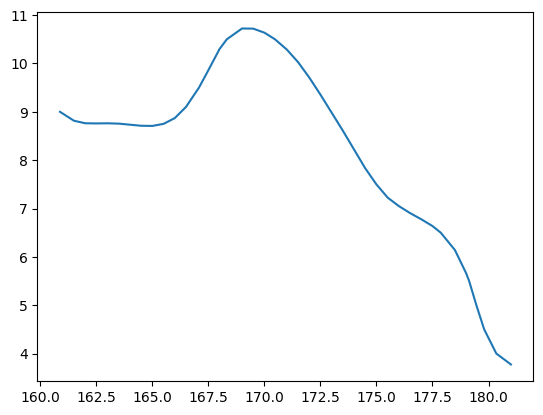

In [17]:
dx = ds_mta.isel(line_id=0, date=0)
plt.plot((dx.longitude + 360) % 360, dx.latitude)

In [18]:
# Compare MTAs with ERA5 IVT (open vertically integrated water vapour (north and east)
wv_files = [
    f"/g/data/rt52/era5/single-levels/reanalysis/viwvn/2021/viwvn_era5_oper_sfc_20211101-20211130.nc",
    f"/g/data/rt52/era5/single-levels/reanalysis/viwve/2021/viwve_era5_oper_sfc_20211101-20211130.nc",
]
ds_ivt = xr.open_mfdataset(wv_files)
ds_ivt["ivt"] = np.sqrt(ds_ivt["p71.162"] ** 2 + ds_ivt["p72.162"] ** 2)
print(ds_ivt)

<xarray.Dataset> Size: 18GB
Dimensions:    (time: 720, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2021-11-01 ... 2021-11-30T23:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    p72.162    (time, latitude, longitude) float64 6GB dask.array<chunksize=(93, 91, 180), meta=np.ndarray>
    p71.162    (time, latitude, longitude) float64 6GB dask.array<chunksize=(93, 91, 180), meta=np.ndarray>
    ivt        (time, latitude, longitude) float64 6GB dask.array<chunksize=(93, 91, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2022-03-02 08:21:00 UTC+1100 by era5_replication_tools-1.10...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis ver

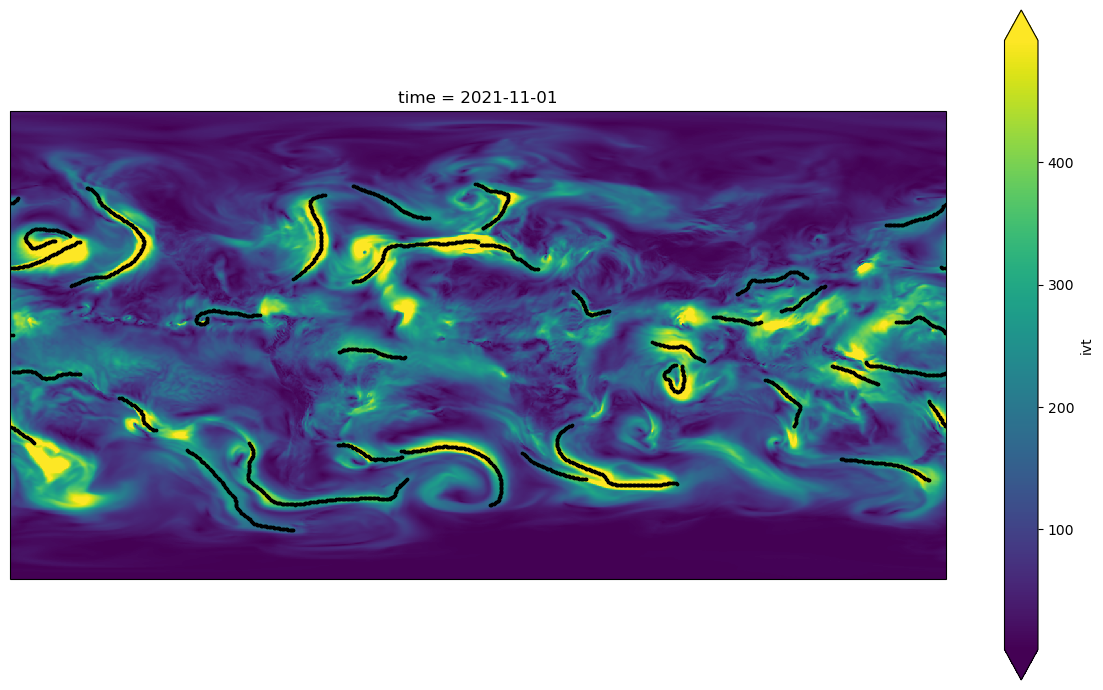

In [19]:
t = 0
plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))

ds_ivt.ivt.isel(time=t).plot(ax=ax, robust=1)

for i in range(ds_mta.line_id.size):
    dx = ds_mta.isel(line_id=i, date=t)
    ax.scatter(
        (dx.longitude + 360) % 360,
        dx.latitude,
        c="k",
        transform=ccrs.PlateCarree(central_longitude=0),
        s=3,
    )
plt.tight_layout()
plt.savefig("/g/data/xv83/as3189/vicwaci/ERA5_IVT_MTA_test.png")

In [24]:
lines, loff = convert_to_dynlib_lines(ds_mta_lines, ds_cyc)
lines, loff

(array([[[  3.     , 173.     , 340.30597],
         [  2.     , 173.     , 325.8088 ],
         [720.     , 172.     , 304.50693],
         ...,
         [      nan,       nan,       nan],
         [      nan,       nan,       nan],
         [      nan,       nan,       nan]],
 
        [[678.     ,  89.     , 187.3191 ],
         [679.     ,  89.     , 192.11888],
         [680.     ,  89.     , 202.00362],
         ...,
         [      nan,       nan,       nan],
         [      nan,       nan,       nan],
         [      nan,       nan,       nan]],
 
        [[705.     , 222.     , 245.16663],
         [706.     , 222.     , 263.2659 ],
         [707.     , 221.     , 285.64032],
         ...,
         [      nan,       nan,       nan],
         [      nan,       nan,       nan],
         [      nan,       nan,       nan]],
 
        ...,
 
        [[118.     , 295.     , 415.2159 ],
         [118.     , 295.     , 425.01282],
         [117.     , 295.     , 425.01282],
         .

In [25]:
shape = (ds_cyc["latitude"].size, ds_cyc["longitude"].size)
mask = dynlib.utils.mask_lines_with_data(
    lines,
    loff,
    shape,
)
mask.shape

(240, 361, 720)

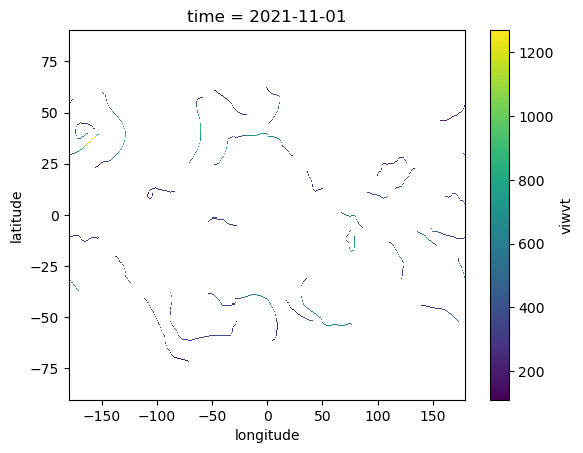

In [26]:
mask = mta_lines_to_mask(ds_mta_lines, ds_cyc)
mask[0].plot()

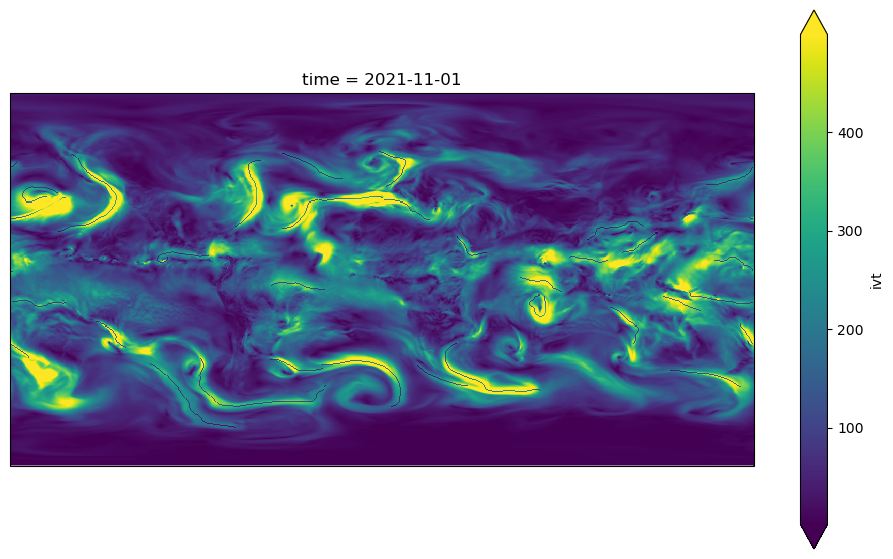

In [27]:
plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ds_ivt.ivt.isel(time=0).plot(ax=ax, robust=1)
ax.pcolormesh(ds_cyc.longitude, ds_cyc.latitude, mask[0])

### Jets

In [28]:
# ERA5 jet objects (not using for precip attr)
ds_jets = xr.open_dataset(f"{path_obj}/jets/ea.ans.{time_str}.pv2000.jetaxis.nc")
ds_jets

<xarray.Dataset> Size: 48MB
Dimensions:     (index: 755882)
Coordinates:
  * index       (index) int64 6MB 0 1 2 3 4 ... 755878 755879 755880 755881
Data variables:
    line_id     (index) int64 6MB ...
    date        (index) datetime64[ns] 6MB ...
    latitude    (index) float64 6MB ...
    longitude   (index) float64 6MB ...
    pres@maxff  (index) float64 6MB ...
    ff@maxff    (index) float64 6MB ...
    pt@maxff    (index) float64 6MB ...

### Cold air outbreaks

In [30]:
file_cao = f"{path_obj}/caoidx/ea.ans.{time_str}.sfc.caoidx.nc"
ds_cao = xr.open_dataset(file_cao)
ds_cao

<xarray.Dataset> Size: 499MB
Dimensions:    (time: 240, latitude: 361, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2021-11-01 ... 2021-11-30T21:00:00
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Data variables:
    caoidx     (time, latitude, longitude) float64 499MB ...
Attributes:
    Conventions:  CF-1.0
    history:      2023-05-05 16:59:26 CEST by 1.3.2-7-g0f42abd

## ERA5 Precipitation
Variable that we want to attribute the weather objects to

In [31]:
# Open ERA5 total precipitation (tp) [m]
file_pr = f"/g/data/rt52/era5/single-levels/reanalysis/tp/{dt.year}/tp_era5_oper_sfc_{time_str}*.nc"
ds_pr = xr.open_mfdataset(file_pr)
ds_pr

<xarray.Dataset> Size: 6GB
Dimensions:    (time: 720, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2021-11-01 ... 2021-11-30T23:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    tp         (time, latitude, longitude) float64 6GB dask.array<chunksize=(93, 91, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-08-19 06:09:38 UTC+1000 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis total_precipitation 20211101-...

In [32]:
# Convert from m to mm
print("Before unit conversion:", ds_pr["tp"].max().load())
# ds_pr['tp'] = units.convert_units_to(ds_pr.tp, "mm")
ds_pr["tp"] *= 1e3
print("After unit conversion:", ds_pr["tp"].max().load())
# ds_pr['tp'] *=1e3

Before unit conversion: <xarray.DataArray 'tp' ()> Size: 8B
array(0.07164383)
After unit conversion: <xarray.DataArray 'tp' ()> Size: 8B
array(71.64382935)


In [33]:
# Convert from hourly to 3hr aggregate preceding each timestep
ds_pr = ds_pr.resample(time="3h", label="right").sum()

# For input time starting at 0000, expect resampled time to start at 0300
print(ds_pr.time[0].load())

# Update units
ds_pr["tp"].attrs["units"] = "m 3hr-1"

<xarray.DataArray 'time' ()> Size: 8B
array('2021-11-01T03:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2021-11-01T03:00:00
Attributes:
    long_name:  time


In [34]:
ds_pr

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 240, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2021-11-01T03:00:00 ... 2021-12-01
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    tp         (time, latitude, longitude) float64 2GB dask.array<chunksize=(31, 91, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-08-19 06:09:38 UTC+1000 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis total_precipitation 20211101-...

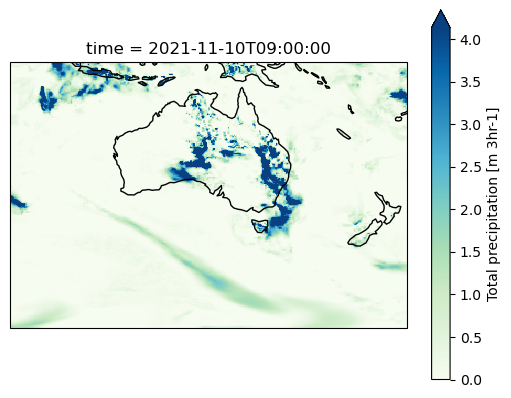

In [35]:
# Plot an interesting snapshot & show domain of subset region
# Pick a date
da_tmp = ds_pr.tp.sel(latitude=slice(-10, -42), longitude=slice(110, 155))
t = da_tmp.sum(["latitude", "longitude"]).idxmax("time").load()

# Plot domain
lat_slice, lon_slice = slice(-5, -65), slice(90, 180)
ax = plt.axes(projection=ccrs.PlateCarree())
ds_pr.tp.sel(time=t, latitude=lat_slice, longitude=lon_slice).plot(
    ax=ax, robust=1, cmap=plt.cm.GnBu
)
ax.coastlines()

### Check alignment of ERA hourly data with with 3hourly features

In [ ]:
file_cyc = f"{path_obj}/cyclones_ETH/ea.ans.198001.sfc.cycmask.nc"
ds_cyc = xr.open_dataset(file_cyc)
print(ds_cyc)

file_msl = f"/g/data/rt52/era5/single-levels/reanalysis/msl/1980/msl_era5_oper_sfc_198001*.nc"
ds_msl = xr.open_mfdataset(file_msl)
print(ds_msl)

<xarray.Dataset> Size: 64MB
Dimensions:    (time: 248, latitude: 361, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 2kB 1980-01-01 ... 1980-01-31T21:00:00
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Data variables:
    cycmask    (time, latitude, longitude) int8 64MB ...
Attributes:
    Conventions:  CF-1.0
    history:      2022-04-11 14:31:06 CEST by 1.2.1-15-ga17189a
<xarray.Dataset> Size: 6GB
Dimensions:    (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6kB 1980-01-01 ... 1980-01-31T23:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    msl        (time, latitude, longitude) float64 6GB dask.array<chunksize=(93, 91, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    hi

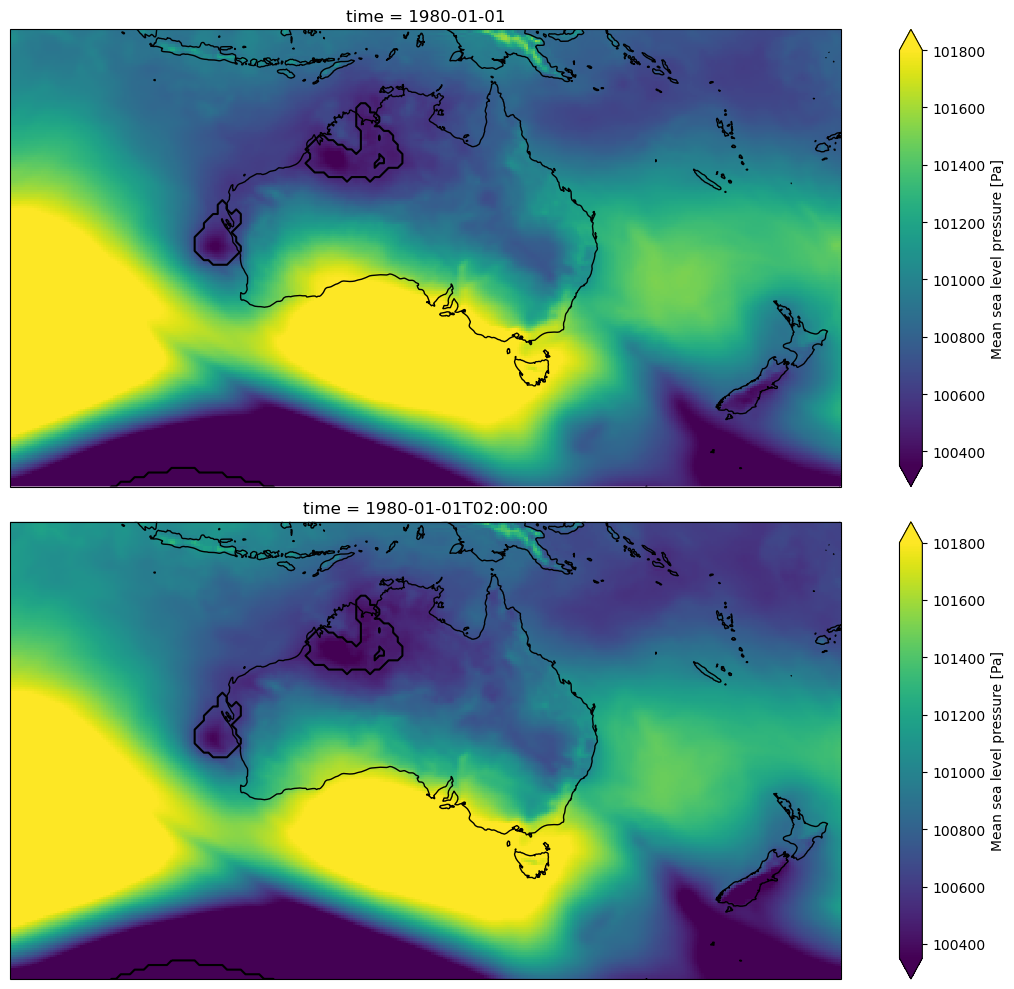

In [37]:
# Check MSL t=0, cyclone t=0
# Check MSL t=2, cyclone t=0
mapcrs = ccrs.PlateCarree(central_longitude=0)
datacrs = ccrs.PlateCarree()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 10),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
# fig.subplots_adjust(hspace=0.4)
axes = axes.flatten()
for ax, t in zip(axes, [0, 2]):
    ax.set_extent([90, 180, -45, -5])
    ds_msl.msl.isel(time=t).plot(ax=ax, vmax=1018e2, vmin=1003.5e2)
    cfC = ax.contour(
        ds_cyc.longitude,
        ds_cyc.latitude,
        ds_cyc.cycmask.isel(time=0) * 1e3,
        colors="k",
        levels=[1],
        alpha=1.0,
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines()
plt.tight_layout()

### Format time alignment

In [16]:
dt = xr.date_range("1980-01-01", "2021-11-01", freq="1MS")[0]
time_str = dt.strftime("%Y%m")
path_features = "/g/data/xv83/as3189/vicwaci/data/weather_features"
file_cyc = f"{path_features}/cyclones_ETH/ea.ans.{time_str}.sfc.cycmask.nc"
ds_cyc = xr.open_dataset(file_cyc)
ds_cyc

<xarray.Dataset> Size: 64MB
Dimensions:    (time: 248, latitude: 361, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 2kB 1980-01-01 ... 1980-01-31T21:00:00
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Data variables:
    cycmask    (time, latitude, longitude) int8 64MB ...
Attributes:
    Conventions:  CF-1.0
    history:      2022-04-11 14:31:06 CEST by 1.2.1-15-ga17189a

In [ ]:
import calendar


def format_filename_dates(dt):
    """Format the start and end dates of a month for ERA5 filenames."""
    start = dt.replace(day=1)
    end = dt.replace(day=calendar.monthrange(dt.year, dt.month)[1])
    return f"{start:%Y%m%d}-{end:%Y%m%d}"


dt = xr.date_range("1980-01-01", "2021-12-01", freq="1MS")[0]
time_str = dt.strftime("%Y%m")
chunks = None

# C: ERA5 cyclones (surface)
file_cyc = f"{path_features}/cyclones_ETH/ea.ans.{time_str}.sfc.cycmask.nc"
ds_cyc = xr.open_dataset(file_cyc, chunks=chunks)
print(ds_cyc.time)
dt_prev = dt - timedelta(days=1)

file_pr_prev = f"/g/data/rt52/era5/single-levels/reanalysis/tp/{dt_prev.year}/tp_era5_oper_sfc_{format_filename_dates(dt_prev)}.nc"
file_pr = f"/g/data/rt52/era5/single-levels/reanalysis/tp/{dt.year}/tp_era5_oper_sfc_{format_filename_dates(dt)}.nc"
print(file_pr)
print(file_pr_prev)
ds_pr = xr.open_mfdataset([file_pr_prev, file_pr], chunks=chunks)

# Convert from hourly to 3hr aggregate preceding each timestep
ds_pr = ds_pr.resample(time="3h", label="right").sum()
print(ds_pr.time)
ds_pr = ds_pr.sel(time=ds_cyc.time)  # Ensure time alignment with cyclones
ds_pr

<xarray.DataArray 'time' (time: 248)> Size: 2kB
array(['1980-01-01T00:00:00.000000000', '1980-01-01T03:00:00.000000000',
       '1980-01-01T06:00:00.000000000', ..., '1980-01-31T15:00:00.000000000',
       '1980-01-31T18:00:00.000000000', '1980-01-31T21:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2kB 1980-01-01 ... 1980-01-31T21:00:00
Attributes:
    long_name:  time
/g/data/rt52/era5/single-levels/reanalysis/tp/1980/tp_era5_oper_sfc_19800101-19800131.nc
/g/data/rt52/era5/single-levels/reanalysis/tp/1979/tp_era5_oper_sfc_19791201-19791231.nc
<xarray.DataArray 'time' (time: 496)> Size: 4kB
array(['1979-12-01T03:00:00.000000000', '1979-12-01T06:00:00.000000000',
       '1979-12-01T09:00:00.000000000', ..., '1980-01-31T18:00:00.000000000',
       '1980-01-31T21:00:00.000000000', '1980-02-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-12-01T03:00:00 ... 1980-02-01
Attribute

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 248, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 2kB 1980-01-01 ... 1980-01-31T21:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    tp         (time, latitude, longitude) float64 2GB dask.array<chunksize=(31, 91, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-09-02 15:30:17 UTC+1000 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis total_precipitation 19791201-...

In [ ]:
ds_cyc.close()
ds_msl.close()

# Test 500hPa cyclone detection

Setup detection of cyclones at 500hPa using `dynlib.detect.cyclone_by_contour`, which requires geopotential height and orography.
Test ERA5 global grid of a single day (3 hour intervals, instead of hourly).

In [14]:
# Pick a date
# dt = xr.date_range("1980-01-01", "2022-12-31", freq="1MS")
dt = xr.date_range("2021-11-01", "2021-11-01", freq="1MS")[0]
time_str = dt.strftime("%Y%m")

In [15]:
# Open geopotential (z) - NB: z on sfc is time invariant, but not on pressure levels
z = xr.open_mfdataset(
    f"/g/data/rt52/era5/pressure-levels/reanalysis/z/{dt.year}/z_era5_oper_pl_{time_str}*.nc"
)
z

<xarray.Dataset> Size: 111GB
Dimensions:    (time: 720, level: 37, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2021-11-01 ... 2021-11-30T23:00:00
  * level      (level) int32 148B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    z          (time, level, latitude, longitude) float32 111GB dask.array<chunksize=(1, 1, 81, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-02-18 10:04:03 UTC+1100 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 pressure-levels oper geopotential 20211101-20211130

In [16]:
%%time
# Select variable at 500hPa
g = 9.80665  # m s-2
z = z.z / g
z.attrs['units'] = 'gpm'
z = z.sel(level=500)
# Subset times
z = z.sel(time=dt.strftime("%Y-%m-%d"))
# Resample times
z = z.resample(time='3h').nearest()
z

CPU times: user 129 ms, sys: 25.5 ms, total: 155 ms
Wall time: 151 ms


<xarray.DataArray 'z' (time: 8, latitude: 721, longitude: 1440)> Size: 33MB
dask.array<getitem, shape=(8, 721, 1440), dtype=float32, chunksize=(1, 81, 180), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 64B 2021-11-01 ... 2021-11-01T21:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
    level      int32 4B 500
Attributes:
    units:    gpm

In [17]:
z_values = np.ascontiguousarray(z.values, dtype=np.float64)

In [18]:
# Open surface geopotential (time invariant)
z_sfc = xr.open_dataset("/g/data/xv83/as3189/vicwaci/data/z_era5_oper_sfc.nc")
print(z_sfc)

<xarray.Dataset> Size: 8MB
Dimensions:    (latitude: 721, longitude: 1440)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    z          (latitude, longitude) float64 8MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2023-11-06 14:14:42 UTC+1100 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis geopotential 19400101-19400131


In [19]:
# Convert to geopotential height [m] (meters above sea level)
z_sfc = z_sfc["z"]
print("original units:", z_sfc.attrs["units"])
g = 9.80665  # m s-2
z_sfc /= g  # m2 s-2 / m s-2 = m
z_sfc.attrs["units"] = "gpm"
print("new units:", z_sfc.attrs["units"])

original units: m**2 s**-2
new units: gpm


In [20]:
# Create grid instance with orography
lon2d, lat2d = np.meshgrid(z_sfc.longitude, z_sfc.latitude)
grid = gridlib.grid_by_latlon(lat2d, lon2d)
grid.oro = np.ascontiguousarray(z_sfc.values, dtype=np.float64)
grid

In [21]:
%%time
dynfor.config.cyc_minprominence = 50
cycmask, cycmeta = dynlib.detect.cyclone_by_contour(z_values, grid)

CPU times: user 18.7 s, sys: 461 ms, total: 19.2 s
Wall time: 18.9 s



cycmask: (time, lat, lon)
    Cyclone mask with different integers designating different cyclones

cycmeta: (time,nn,5)
    cycmeta data about each cyclone: (1) latitude and (2) longitude of centre, (3) minimum SLP, (4) SLP at the outermost contour, and (5) cyclone size.
    nn = 1000 (Maximum number of cyclones to be detected)

In [23]:
# Should have dims (time, lat, lon) with a unique integer for each cyclone
print("cycmask shape:", cycmask.shape)
cycmask = xr.DataArray(cycmask, dims=z.dims, coords=z.coords, name="cycmask")
# Should have dims (time, 1000, 5) - NB max number of cyclones manually set to 1000
print("cycmeta shape:", cycmeta.shape)
cycmeta = xr.DataArray(cycmeta, dims=("time", "cid", "info"))
cycmeta = cycmeta.where(cycmeta != 0, drop=1).dropna("cid", how="all")
print("cycmeta shape:", cycmeta.shape)
cycmask = cycmask.to_dataset()
cycmask

cycmask shape: (8, 721, 1440)
cycinfo shape: (8, 1000, 5)
cycinfo shape: (8, 33, 5)


<xarray.Dataset> Size: 33MB
Dimensions:    (longitude: 1440, latitude: 721, time: 8)
Coordinates:
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 64B 2021-11-01 ... 2021-11-01T21:00:00
    level      int32 4B 500
Data variables:
    cycmask    (time, latitude, longitude) int32 33MB 0 0 0 0 0 0 ... 0 0 0 0 0

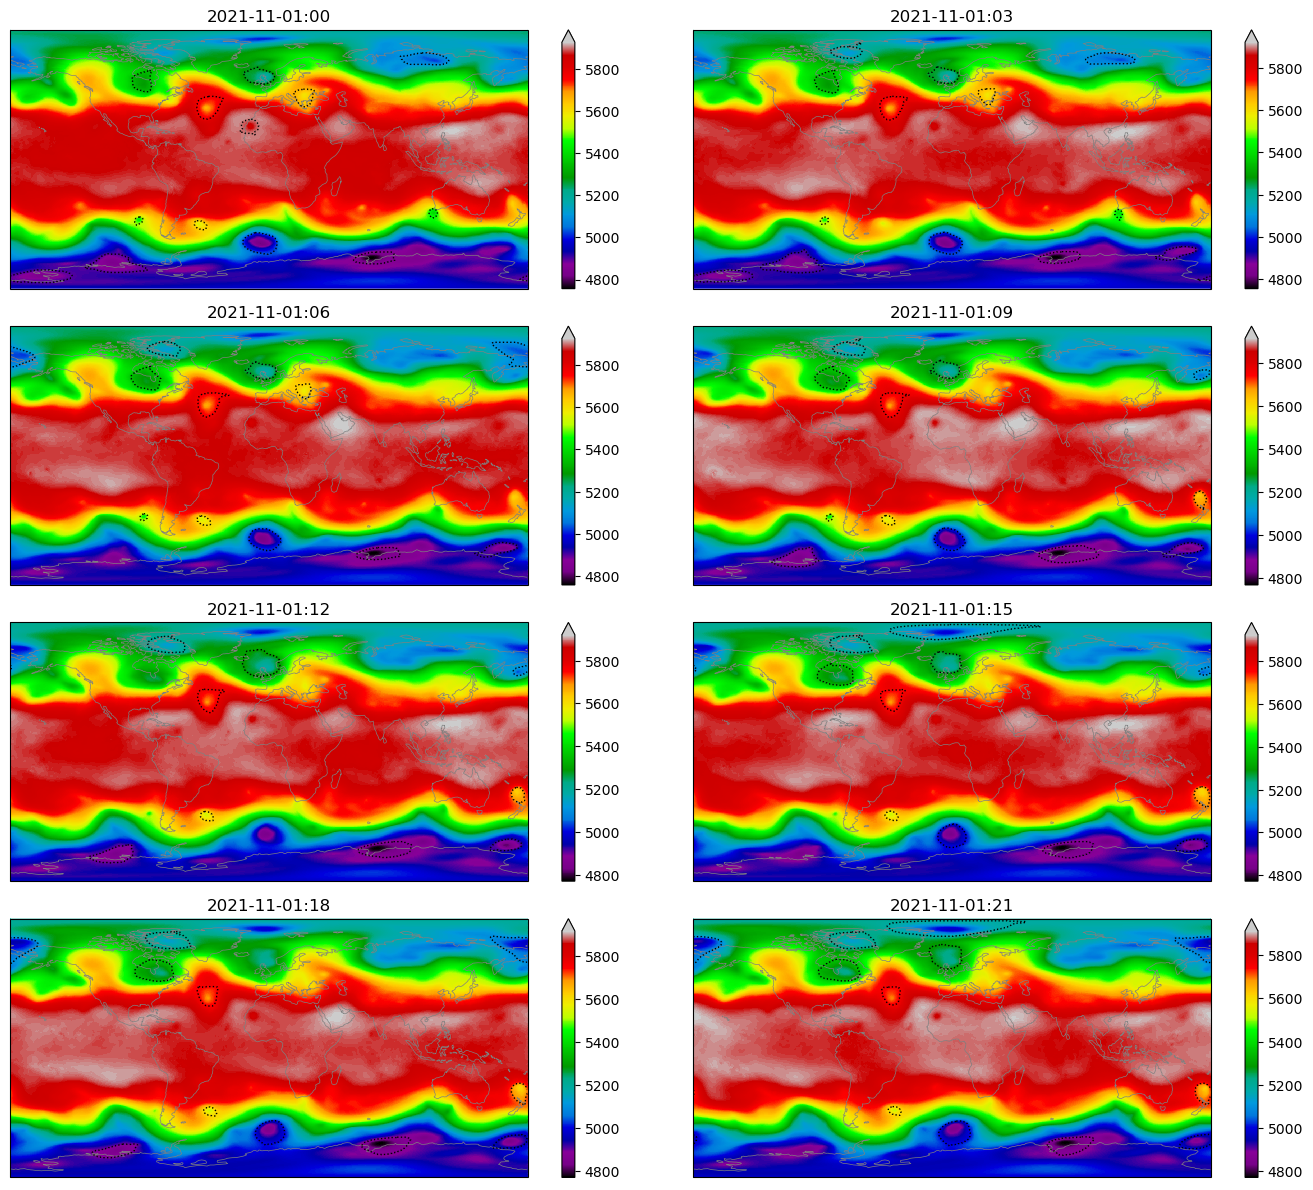

In [21]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 12),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
axes = axes.flatten()
# z.isel(time=t).plot(ax=ax)
for t, ax in zip(np.arange(z.time.size), axes):
    ax.set_title(z.isel(time=t).time.dt.strftime("%Y-%m-%d:%H").item())
    ax.coastlines(color="gray", linewidth=0.5)
    cm = ax.pcolormesh(
        z.longitude,
        z.latitude,
        z_values[t],
        cmap=plt.cm.nipy_spectral,
        transform=ccrs.PlateCarree(),
    )
    plt.colorbar(cm, extend="max")
    cf = ax.contour(
        cycmask.longitude,
        cycmask.latitude,
        xr.where(cycmask.cycmask != 0, 1, 0).isel(time=t) * 1e3,
        colors="k",
        levels=[1],
        linestyles=":",
        linewidths=1,
        alpha=1.0,
        transform=ccrs.PlateCarree(),
    )

plt.tight_layout()

Compare with another value of cyc_minprominence 

In [ ]:
%%time
dynfor.config.cyc_minprominence = 10
cycmask_10, cycmeta_10 = dynlib.detect.cyclone_by_contour(z_values, grid)

In [ ]:
# Should have dims (time, lat, lon) with a unique integer for each cyclone
print("cycmask shape:", cycmask_10.shape)
cycmask_10 = xr.DataArray(cycmask_10, dims=z.dims, coords=z.coords)
# Should have dims (time, 1000, 5) - NB max number of cyclones manually set to 1000
print("cycmeta shape:", cycmeta_10.shape)
cycmeta_10 = xr.DataArray(cycmeta_10, dims=("time", "cid", "info"))
cycmeta_10 = cycmeta_10.where(cycmeta_10 != 0, drop=1).dropna("cid", how="all")
print("cycmeta shape:", cycmeta_10.shape)

In [ ]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 12),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
axes = axes.flatten()

for t, ax in zip(np.arange(z.time.size), axes):
    ax.set_title(z.isel(time=t).time.dt.strftime("%Y-%m-%d:%H").item())
    ax.coastlines(color="gray", linewidth=0.5)
    cm = ax.pcolormesh(
        z.longitude,
        z.latitude,
        z.isel(time=t),
        cmap=plt.cm.nipy_spectral,
        transform=ccrs.PlateCarree(),
    )
    plt.colorbar(cm, extend="max")

    cf = ax.contour(
        cycmask.longitude,
        cycmask.latitude,
        xr.where(cycmask != 0, 1, 0).isel(time=t) * 1e3,
        colors="k",
        levels=[1],
        # linestyles=':',
        linewidths=1.5,
        alpha=1.0,
        transform=ccrs.PlateCarree(),
    )
    cf = ax.contour(
        cycmask.longitude,
        cycmask.latitude,
        xr.where(cycmask_10 != 0, 1, 0).isel(time=t) * 1e3,
        colors="w",
        levels=[1],
        linestyles=":",
        linewidths=1.2,
        alpha=1.0,
        transform=ccrs.PlateCarree(),
    )
plt.tight_layout()

#### Examine surface vs 500hPa cyclone differences

In [ ]:
dtlist = xr.date_range("1980-01-01", "2021-12-01", freq="1MS")
ds = []
dt = dtlist[0]
cyc_minprominence = 30
# for dt in tqdm(dtlist[:1]):
#     ds.append(ds_cyc.where((ds_cyc_500.cycmask != ds_cyc.cycmask)))
# dss = xr.concat(ds, 'time')
# dss
time_str = dt.strftime("%Y")
ds_cyc = xr.open_mfdataset(f"{path_obj}/cyclones_ETH/ea.ans.{time_str}*.sfc.cycmask.nc")
ds_cyc_500 = xr.open_mfdataset(
    f"{path_obj}/cyclones_500hpa/ea.ans.{time_str}*.500.cycmask_min{cyc_minprominence}gpm.nc"
)
overlap = ds_cyc.cycmask & ds_cyc_500.cycmask

In [ ]:
m1 = ds_cyc.cycmask.astype(bool)
m2 = ds_cyc_500.cycmask.astype(bool)

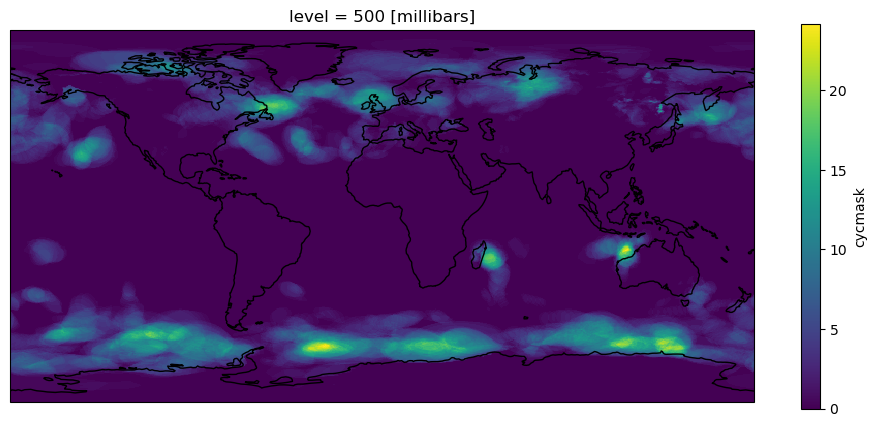

In [31]:
# Percentage of times that both masks contain cyclones
overlap_pct = ((m1 & m2).sum(dim="time") / m1.time.size) * 100

plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines()
overlap_pct.plot(ax=ax)

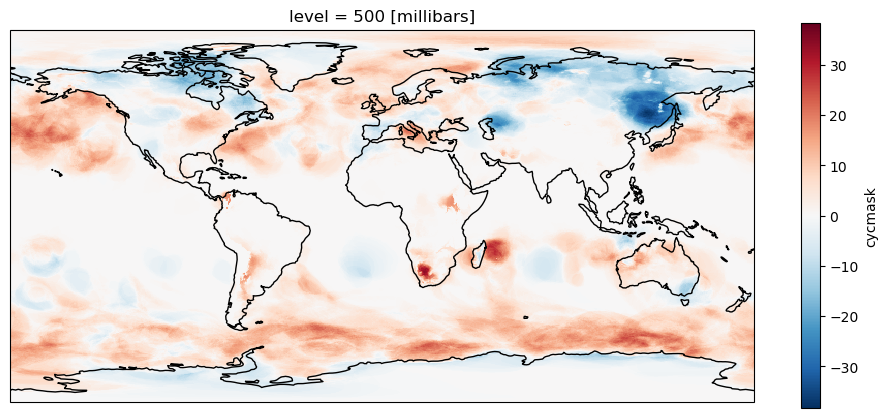

In [30]:
# +20  → surface identified 20 pp. more often than 500 hPa.
#   0  → same occurrence frequency
# -20  → 500 hPa identified 20 pp. more often.
frequency_difference = (m1.mean("time") - m2.mean("time")) * 100

plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines()
frequency_difference.plot(ax=ax)

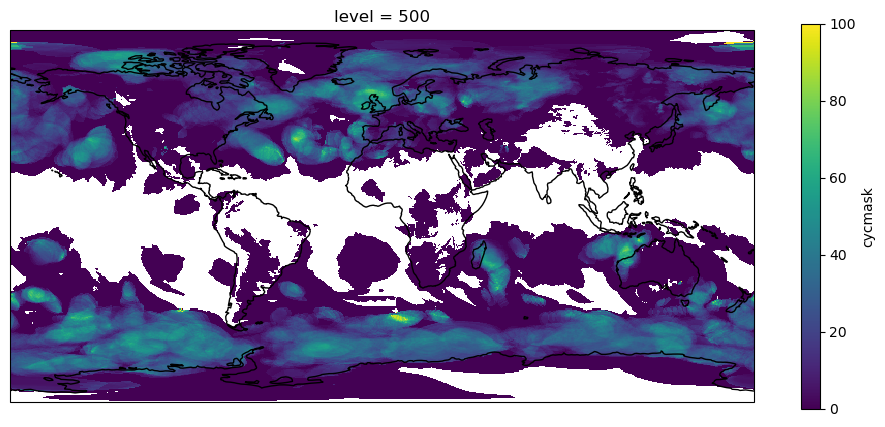

In [ ]:
# Of all times when either dataset identified this grid cell as part of a cyclone, what percentage of those times did both datasets identify it?
intersection = (m1 & m2).sum(dim="time")
union = (m1 | m2).sum(dim="time")

jaccard_pct = (intersection / union) * 100
jaccard_pct = xr.where(union > 0, intersection / union * 100, float("nan"))
plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines()
jaccard_pct.plot(ax=ax)

In [ ]:
# diff = dss.cycmask.where(dss.cycmask !=0).dropna('time', how='all')
# diff
t = 0

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 10),
    facecolor="w",
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
fig.subplots_adjust(hspace=0.4)
axes = axes.flatten()
for t, ax in enumerate(axes):
    # Cyclones (black lines)
    ax.coastlines(color="grey", linewidth=1)
    ax.set_extent([90, 180, -65, -5])
    ax.set_title(ds_cyc.isel(time=t).time.dt.strftime("%Y-%m-%d:%H").item())
    cfC = ax.contour(
        ds_cyc.longitude,
        ds_cyc.latitude,
        ds_cyc.cycmask.isel(time=t) * 1e3,
        colors="black",
        levels=[1],
        alpha=1.0,
        transform=ccrs.PlateCarree(),
    )
    # Cyclones (black lines)
    cfC = ax.contour(
        ds_cyc_500.longitude,
        ds_cyc_500.latitude,
        ds_cyc_500.cycmask.isel(time=t) * 1e3,
        colors="hotpink",
        linestyles="--",
        levels=[1],
        alpha=1.0,
        transform=ccrs.PlateCarree(),
    )

In [ ]:
dtlist = xr.date_range("1980-01-01", "2021-12-01", freq="1MS")
ds = []
# for dt in tqdm(dtlist[:1]):
dt = dtlist[0]
time_str = dt.strftime("%Y%m")
# Open ERA5 cyclone objects
file_cyc = f"{path_obj}/cyclones_ETH/ea.ans.{time_str}.sfc.cycmask.nc"
ds_cyc = xr.open_dataset(file_cyc, chunks=chunks)

file_cyc_500 = (
    f"{path_obj}/cyclones_500hpa/ea.ans.{time_str}.500.cycmask_min{cyc_minprominence}gpm.nc"
)
ds_cyc_500 = xr.open_dataset(file_cyc_500, chunks=chunks).squeeze()
ds_cyc_500.cycmask

<xarray.DataArray 'cycmask' (time: 248, latitude: 721, longitude: 1440)> Size: 257MB
[257483520 values with dtype=int8]
Coordinates:
  * time       (time) datetime64[ns] 2kB 1980-01-01 ... 1980-01-31T21:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
    level      int32 4B ...
Attributes:
    long_name:    Cyclone detection mask
    units:        (0-1)
    description:  Mask of cyclones detected at 500 hPa in ERA5 using dynlib.d...

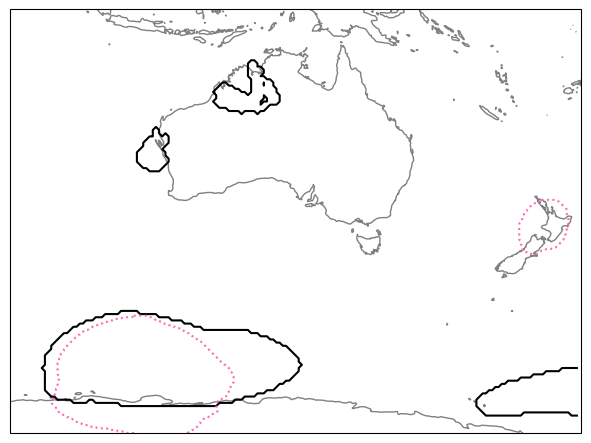

In [ ]:
t = 0
fig, ax = plt.subplots(
    figsize=(12, 5.5),
    facecolor="w",
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
)
fig.subplots_adjust(hspace=0.4)
ax.coastlines(color="grey", linewidth=1)
ax.set_extent([90, 180, -65, -5])

# Cyclones (black lines)
cfC = ax.contour(
    ds_cyc.longitude,
    ds_cyc.latitude,
    ds_cyc.cycmask.isel(time=t) * 1e3,
    colors="black",
    levels=[1],
    alpha=1.0,
    transform=ccrs.PlateCarree(),
)
# Cyclones (black lines)
cfC = ax.contour(
    ds_cyc_500.longitude,
    ds_cyc_500.latitude,
    ds_cyc_500.cycmask.isel(time=t) * 1e3,
    colors="hotpink",
    linestyles=":",
    levels=[1],
    alpha=1.0,
    transform=ccrs.PlateCarree(),
)

In [ ]:
cycmask.close()
cycmeta.close()
cycmask_10.close()
cycmeta_10.close()

### Sensitivity analysis

Unfinished

In [ ]:
dplist = [10, 20, 30, 40, 50]

date_range = xr.date_range("1981-01-01", f"1981-12-31", freq="1MS")
path_features = (
    "/g/data/xv83/as3189/vicwaci/data/weather_features/cyclones_500hpa/sensitivity_analysis"
)

dp = []
for p in tqdm(dplist):
    files = f"{path_features}/min{p}gpm/ea.ans.*.500.cycmask.nc"
    dx = xr.open_mfdataset(files)
    dx["cycmask"] = dx.cycmask.assign_coords(p=p)
    dp.append(dx)
dp = xr.concat(dp, "p")
dp

100%|██████████| 5/5 [00:00<00:00,  8.31it/s]


<xarray.Dataset> Size: 15GB
Dimensions:    (p: 5, time: 2920, latitude: 721, longitude: 1440)
Coordinates:
  * p          (p) int64 40B 10 20 30 40 50
  * time       (time) datetime64[ns] 23kB 1981-01-01 ... 1981-12-31T21:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
    level      int32 4B 500
Data variables:
    cycmask    (p, time, latitude, longitude) int8 15GB dask.array<chunksize=(1, 83, 241, 480), meta=np.ndarray>
Attributes:
    history:  2026-09-10 19:53:27: Created /g/data/xv83/as3189/vicwaci/data/w...

# Run attribution

In [ ]:
def format_filename_dates(dt):
    """Format the start and end dates of a month for ERA5 filenames."""
    start = dt.replace(day=1)
    end = dt.replace(day=calendar.monthrange(dt.year, dt.month)[1])
    return f"{start:%Y%m%d}-{end:%Y%m%d}"


path_features = "/g/data/xv83/as3189/vicwaci/data/weather_features"
path_output = "/g/data/xv83/as3189/vicwaci/data/precip_attribution"

min_precip_mm = 0.1  # Minimum precipitation (mm) threshold
cyc_minprominence = 30  # used for cyclones at 500hPa
# Domain boundary (applied before attribution)
lat_slice, lon_slice = slice(-5, -65), slice(90, 180)
encoding = {
    "zlib": True,
    "complevel": 4,
    "shuffle": True,
}

dtlist = xr.date_range("1980-01-01", "2021-12-01", freq="1MS")
for dt in tqdm(dtlist[:1]):
    time_str = dt.strftime("%Y%m")
    print(time_str)
    chunks = None

    # C: ERA5 cyclones (surface)
    file_cyc = f"{path_features}/cyclones_ETH/ea.ans.{time_str}.sfc.cycmask.nc"
    ds_cyc = xr.open_dataset(file_cyc, chunks=chunks)

    # V: ERA5 cyclones (at 500 hPa)
    file_cyc_500 = f"{path_features}/cyclones_500hpa/ea.ans.{time_str}.500.cycmask_min{cyc_minprominence}gpm.nc"
    ds_cyc_500 = xr.open_dataset(file_cyc_500, chunks=chunks)
    ds_cyc_500 = ds_cyc_500.drop_vars("level")

    # F: ERA5 fronts
    file_fronts = f"{path_features}/fronts/ea.ans.{time_str}.850.frovo_id.nc"
    ds_fronts = xr.open_dataset(file_fronts, chunks=chunks)
    ds_fronts = ds_fronts.isel(lev=0, drop=True)

    # M: ERA5 MTAs
    file_mta = f"{path_features}/mta/ea.ans.{time_str}.sfc.mta.nc"
    ds_mta_lines = xr.open_dataset(file_mta, chunks=chunks)
    ds_mta = mta_lines_to_mask(ds_mta_lines, ds_cyc)
    ds_mta = xr.where(~np.isnan(ds_mta), ds_mta, 0)

    # Open ERA5 precip (tp)
    # Open the previous day's file as well to ensure we have the full 3-hourly aggregation for the first timestep of the current day.
    dt_prev = dt - timedelta(days=1)
    file_pr_prev = f"/g/data/rt52/era5/single-levels/reanalysis/tp/{dt_prev.year}/tp_era5_oper_sfc_{format_filename_dates(dt_prev)}.nc"
    file_pr = f"/g/data/rt52/era5/single-levels/reanalysis/tp/{dt.year}/tp_era5_oper_sfc_{format_filename_dates(dt)}.nc"

    ds_pr = xr.open_mfdataset([file_pr_prev, file_pr], chunks=chunks)
    # Convert from hourly to 3hr aggregate preceding each timestep
    ds_pr = ds_pr.resample(time="3h", label="right").sum()
    ds_pr = ds_pr.sel(time=ds_cyc.time)  # Ensure time alignment with cyclones

    # Update units
    ds_pr["tp"] *= 1e3
    ds_pr["tp"].attrs["units"] = "mm 3hr-1"

    # Apply minimum precipitation threshold
    ds_pr = ds_pr.where(ds_pr > min_precip_mm)

    # Create a DataArray with the same dimensions and coordinates
    dims = list(ds_cyc.dims)
    coords = {dim: ds_cyc[dim].values for dim in dims}

    # Create dataset of variables
    da = xr.Dataset(None, coords=ds_cyc.coords)
    da["tp"] = ds_pr["tp"]
    da["C"] = ds_cyc.cycmask > 0
    da["V"] = ds_cyc_500.cycmask > 0
    da["F"] = ds_fronts.frovo_id > 0
    da["M"] = xr.DataArray(ds_mta != 0, dims=dims, coords=coords, name="mta")

    # Create mask conditions (letters correspond to the variable in the dataset)
    masks_conditions = [
        ("C", lambda x: (x.C > 0)),  # cyclone mask
        ("V", lambda x: (x.V > 0)),  # cyclone mask (500hPa)
        ("F", lambda x: (x.F > 0)),  # front mask
        ("M", lambda x: (x.M > 0)),  # MTA mask (lines)
    ]

    # Subset the data to the domain of interest (Australia)
    da = da.sel(latitude=lat_slice, longitude=lon_slice)

    print("Run attribution")
    # https://git.app.uib.no/Clemens.Spensberger/dynlib/-/blob/master/lib/utils.py?ref_type=heads#L997
    # Factor of -1 (indicates precip maxima rather than minima)
    ds = utils.attribute_to_features(da, masks_conditions, var="tp", factor=-1)

    for i, v in enumerate(tqdm(list(ds.data_vars))):
        if i == 0:
            total_vars = ds[v]
        else:
            total_vars = total_vars + ds[v]

    # Add total precipitation to the dataset
    ds["total"] = total_vars.rename("total")

    # Add cycmetadata to the dataset
    ds["C"].attrs["description"] = "Precipitation attributed to surface cyclones"
    ds["V"].attrs["description"] = "Precipitation attributed to cyclones at 500 hPa"
    ds["F"].attrs["description"] = "Precipitation attributed to fronts"
    ds["M"].attrs["description"] = "Precipitation attributed to moisture transport axis (lines)"
    ds["U"].attrs["description"] = "Unattributed precipitation"
    ds["total"].attrs[
        "description"
    ] = f"Total precipitation > {min_precip_mm} mm 3hr-1 (attributed and unattributed)"
    ds.attrs["description"] = (
        f"Precipitation attribution to weather features (cyclones, fronts, moisture transport axis) for ERA5 over Australia. Minimum precipitation threshold: {min_precip_mm} mm 3hr-1. Cyclone detection at 500hPa with minimum prominence of {cyc_minprominence} gpm."
    )
    ds.attrs["history"] = (
        f"Created by precip_attribute_weather_features.py on {dt.strftime('%Y-%m-%d %H:%M:%S')}"
    )
    ds.attrs["history"] = f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')} by {dynlib.version}"

    encoding = {var: encoding for var in ds.data_vars}
    # ds.to_netcdf(outfile, compute=True, encoding=encoding)
    # print(f"Saved attribution to {outfile}")

    ds_cyc.close()
    ds_cyc_500.close()
    ds_fronts.close()
    ds_mta_lines.close()
    ds_mta.close()
    ds_pr.close()

ds

In [8]:
list(ds.data_vars)

['U',
 'M',
 'F',
 'FM',
 'V',
 'VM',
 'VF',
 'VFM',
 'C',
 'CM',
 'CF',
 'CFM',
 'CV',
 'CVM',
 'CVF',
 'CVFM',
 'total']

# Plot attribution results

In [12]:
# Pick a rainy day
da_tmp = ds_pr.tp.sel(latitude=slice(-10, -42), longitude=slice(110, 155))
t = da_tmp.sum(["latitude", "longitude"]).idxmax("time").load()
t
da_tmp = ds_pr.tp.sel(latitude=slice(-10, -42), longitude=slice(110, 155))
t = da.time[0]
t

<xarray.DataArray 'time' ()> Size: 8B
array('1980-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 1980-01-01

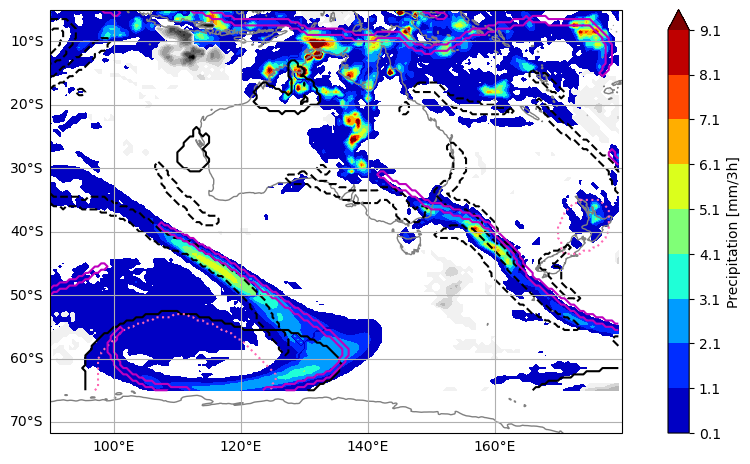

In [ ]:
mapcrs = ccrs.PlateCarree(central_longitude=0)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor="w", subplot_kw={"projection": mapcrs})
fig.subplots_adjust(hspace=0.4)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", lw=1)
ax.set_extent([90, 180, -65, -5])

# Cyclones (black lines)
cfC = ax.contour(
    da.longitude,
    da.latitude,
    da["C"].sel(time=t) * 1e3,
    colors="black",
    levels=[1],
    alpha=1.0,
    transform=datacrs,
)
# Cyclones (black lines)
cfC = ax.contour(
    da.longitude,
    da.latitude,
    da["V"].sel(time=t) * 1e3,
    colors="hotpink",
    linestyles=":",
    levels=[1],
    alpha=1.0,
    transform=datacrs,
)
# Fronts (dashed)
cfC = ax.contour(
    da.longitude,
    da.latitude,
    da["F"].sel(time=t) * 1e3,
    colors="k",
    linestyles="--",
    levels=[1],
    alpha=1.0,
    transform=datacrs,
)
# MTAs
cfC = ax.contour(
    da.longitude,
    da.latitude,
    da["M"].sel(time=t) * 1e3,
    colors="m",
    # linestyles="--",
    levels=[1],
    alpha=1.0,
    transform=datacrs,
)
for var in [v for v in ds.data_vars if v not in ["total", "U"]]:
    cfC = ax.contourf(
        da.longitude,
        da.latitude,
        ds[var].sel(time=t),
        cmap=cmaps.MPL_jet,
        levels=np.arange(0.1, 10),
        extend="max",
        alpha=1.0,
        transform=datacrs,
    )

cfU = ax.contourf(
    da.longitude,
    da.latitude,
    ds["U"].sel(time=t),
    cmap="gray_r",
    levels=np.arange(0.1, 10),
    extend="max",
    alpha=1.0,
    transform=datacrs,
)
plt.colorbar(cfC, label="Precipitation [mm/3h]")
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False